# Task 2: training a 100-genre classifier on the chatbot's own LLM

This notebook walks you through training the Task 2 classifier one step at a time. Every code cell has a short explanation above it saying **what** it does and **why** it is done that way, because the interview will ask you about these choices.

**What we build.** The same `Qwen3-4B-Instruct-2507` that powers the Task 1 chatbot, loaded once in 4-bit. On top of it we add two small trainable pieces:

1. a **LoRA adapter** (a few million extra weights inside the attention and MLP layers), and
2. a **classification head**: one linear layer that turns the hidden state of the last token into 100 genre scores.

```
                    ┌──────────────── frozen Qwen3-4B (4-bit NF4) ────────────────┐
story tokens  ──►   │  layer 1 … layer 36   (+ LoRA adapter, can be switched off)  │ ──► last-token hidden state ──► Linear(2560 → 100) ──► genre
                    └──────────────────────────────────────────────────────────────┘
chat question ──►   same layers with the adapter OFF  ──► lm_head ──► answer   (identical to the untouched base model)
```

**Why this design preserves the chatbot.** The base weights are frozen and never change. The chatbot runs inside `with model.disable_adapter():`, so it computes with exactly the original weights. We will *prove* this at the end by comparing the chatbot's answers before and after training, token for token.

**Roadmap**

| Part | What you do | What you learn |
|---|---|---|
| 0 | Set up Colab, Drive and the config | Why fp16 on a T4, why save to Drive |
| 1 | Load and inspect the data, map labels | Label hygiene |
| 2 | Freeze a stratified 7/1/2 split | Why stratify, why freeze it |
| 3 | Turn stories into model inputs | Truncation, the prompt suffix, padding |
| 4 | Train a cheap baseline | What accuracy is "good" here |
| 5 | Load the 4-bit model, snapshot the chatbot | NF4 quantization, the "before" evidence |
| 6 | Add LoRA and the head | What LoRA trains, last-token pooling |
| 7 | Train with checkpoints | fp16 + GradScaler, accumulation, schedules, early stopping |
| 8 | Read the curves | How metrics evolve |
| 9 | Test-set evaluation | Per-genre metrics, confusion matrix |
| 10 | Prove the chatbot is unchanged | `disable_adapter()`, weight checksums |
| 11 | Save, reload and predict | Serving both tasks from one model |

**Before you run it.** Runtime → Change runtime type → **T4 GPU**. Then do a **quick dry run first**: set `QUICK_RUN = True` in the config cell. It swaps in the small `Qwen3-0.6B` and one epoch, so the whole notebook finishes in minutes and any bug shows up cheaply. When that works, set it back to `False` for the real run.

## Part 0. Setup

### 0.1 Install libraries

- `transformers` loads Qwen, `peft` adds LoRA, `bitsandbytes` does the 4-bit quantization, `accelerate` places the model on the GPU.
- `datasets` downloads the stories from the Hugging Face Hub; `scikit-learn` gives us splits and metrics.

After this cell finishes, Colab sometimes asks you to restart the runtime. If it does, restart and continue from the next cell.

In [ ]:
!pip -q install -U transformers peft accelerate bitsandbytes datasets scikit-learn

### 0.2 Check the GPU

The free Colab T4 has 16 GB and **no bfloat16 support**. That single fact drives several choices below: we compute in **float16**, and because float16 has a small range we need a gradient scaler during training (Part 7).

In [ ]:
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0), f"| {torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GB")
    print("bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("No GPU: Runtime -> Change runtime type -> T4 GPU")

torch 2.11.0+cu130 | CUDA available: True
Tesla T4 | 14.6 GB
bf16 supported: True


### 0.3 Mount Google Drive

Free Colab sessions disconnect after a few hours or when idle, and everything on the VM disappears. So every result that took time to compute (the split, the "before" chatbot answers, checkpoints, the trained adapter) goes to Drive. If the session dies, re-run the notebook from the top: each step finds its saved output and skips or resumes.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content/drive/My Drive/LORA


In [ ]:
%cd /content/drive/MyDrive/LORA

/content/drive/MyDrive/LORA


In [ ]:
!pwd

/content/drive/MyDrive/LORA


### 0.4 Configuration

All the knobs live in one cell so you can see the whole experiment at a glance and copy it into your write-up. The reason for each value is in the comment next to it; the brief asks you to justify every hyperparameter, so these comments are your first draft of that table.

In [ ]:
from pathlib import Path

QUICK_RUN = False          # True = Qwen3-0.6B and 1 epoch, to test the whole notebook in minutes

MODEL_ID   = "Qwen/Qwen3-0.6B" if QUICK_RUN else "Qwen/Qwen3-4B-Instruct-2507"   # same LLM as the Task 1 chatbot
DATASET_ID = "FareedKhan/1k_stories_100_genre"
SEED = 42

# Inputs
MAX_LEN   = 1024           # tokens per story; check in Part 3 that this covers ~p95 of story lengths
USE_TITLE = True           # titles may hint at the genre; try both and report it (ablation)

# LoRA
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05   # common starting point; alpha = 2*r keeps the update scale stable
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]  # all linear layers

# Optimisation
LR_LORA  = 1e-4            # standard LoRA range on small data
LR_HEAD  = 1e-3            # the head starts from random numbers, so it can learn faster than the adapter
WEIGHT_DECAY_HEAD = 0.01
EPOCHS   = 1 if QUICK_RUN else 8
BATCH_SIZE = 2             # stories per forward pass; 2 x 1024 tokens fits a T4 with gradient checkpointing
GRAD_ACCUM = 8             # 2 x 8 = effective batch 16
WARMUP_RATIO = 0.05
MAX_GRAD_NORM = 1.0
PATIENCE = 3               # stop if validation macro-F1 has not improved for 3 epochs
EVAL_BATCH_SIZE = 4

# Where everything is saved (one folder per model so quick runs never mix with real ones)
DRIVE_ROOT = Path("/content/drive/MyDrive/LORA/story-chatbot")
OUT_DIR    = DRIVE_ROOT / "task2" / MODEL_ID.split("/")[-1]
SPLITS_PATH = DRIVE_ROOT / "data" / "splits.json"   # shared with Task 1: both tasks must use the same split
for p in (OUT_DIR, SPLITS_PATH.parent):
    p.mkdir(parents=True, exist_ok=True)
print("saving to", OUT_DIR)

saving to /content/drive/MyDrive/LORA/story-chatbot/task2/Qwen3-4B-Instruct-2507


### 0.5 Seeds

Fixing every random seed makes the run repeatable: same split, same head initialisation, same batch order. You will still see small differences between runs on a GPU, which is why the plan suggests reporting the final model over 3 seeds.

In [ ]:
import os, random, json, math, time, gc
import numpy as np

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = DEVICE.type == "cuda"      # mixed precision only on the GPU

## Part 1. Load and inspect the data

The dataset has 1,000 stories with the fields `id`, `title`, `story` and `genre`. Before training anything, look at a row with your own eyes and check the basic facts the EDA notebook (`analysis/eda_1k_stories_100_genre.ipynb`) covers in depth: stories per genre, empty texts, duplicate ids.

In [ ]:
import pandas as pd
from datasets import load_dataset

raw = load_dataset(DATASET_ID)
print(raw)
df = raw[list(raw.keys())[0]].to_pandas()

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'story', 'genre'],
        num_rows: 1000
    })
})


In [ ]:
for col in ["id", "title", "story", "genre"]:
    assert col in df.columns, f"missing column {col}; columns are {list(df.columns)}"

df["id"] = df["id"].astype(str)
for col in ["title", "story", "genre"]:
    df[col] = df[col].astype(str).str.strip()

print("rows:", len(df), "| unique ids:", df["id"].nunique(), "| empty stories:", (df["story"] == "").sum())
print("genres:", df["genre"].nunique())
print("stories per genre:", df["genre"].value_counts().describe()[["min", "50%", "max"]].to_dict())
df = df[df["story"] != ""].drop_duplicates("id").reset_index(drop=True)

row = df.iloc[0]
print(f"\nExample | id={row.id} | genre={row.genre} | title={row.title}\n{row.story[:600]}...")

rows: 1000 | unique ids: 1000 | empty stories: 0
genres: 99
stories per genre: {'min': 10.0, '50%': 10.0, 'max': 20.0}

Example | id=457580 | genre=Science Fiction | title=The Chronicles of the Cosmic Rift
In the year 2250, Earth had made significant strides in space exploration and interstellar travel. The United Earth Government (UEG) had established colonies on Mars, Jupiter's moon Europa, and Saturn's moon Titan. The advancements in technology and science had led to the creation of the Cosmic Rift Exploration Agency (CREA), a government-funded organization tasked with exploring the unknown regions of space and discovering new worlds and resources.

    Dr. Amelia Hart, a brilliant astrophysicist, was the lead scientist at CREA's headquarters on Luna. She had devoted her entire life to unders...


### 1.1 Map genres to numbers

A neural network outputs 100 numbers, so each genre needs a fixed integer id. We sort the names so the mapping is the same every run, and save it next to the model: at prediction time you need it to turn "output 37" back into "Space Opera".

**Label hygiene:** if the same genre appeared as `Sci-Fi` and `sci fi`, it would silently become two classes. The EDA notebook checks for this; here we just assert it.

In [ ]:
import re
genres = sorted(df["genre"].unique())
norm = lambda s: re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()
assert len({norm(g) for g in genres}) == len(genres), "two genre names differ only by case/punctuation; merge them first"

label2id = {g: i for i, g in enumerate(genres)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(genres)
df["label"] = df["genre"].map(label2id)
json.dump(label2id, open(OUT_DIR / "label2id.json", "w"), indent=1)
print(NUM_LABELS, "classes, e.g.", genres[:5])

99 classes, e.g. ['Adventure', 'Alternate Dimension', 'Alternate History', 'Alternate Reality', 'Animal Fantasy']


## Part 2. Freeze a stratified 7 / 1 / 2 split

With about 10 stories per genre, a plain random split could leave a genre with zero test stories, or put all its stories in training. **Stratifying** splits *each genre* separately: 7 train, 1 validation, 2 test. That gives 700 / 100 / 200 stories.

- **train** is what the model learns from.
- **validation** is what we watch during training to pick the best epoch and decide when to stop. Because we make decisions with it, it is no longer an unbiased estimate.
- **test** is touched once, at the very end, to report the final numbers.

The split is saved to Drive and reused. **Freeze it once and never re-draw it**: Task 1's evaluation, the baselines and every Task 2 experiment must see the same split, or comparisons between them are meaningless. If your Task 1 work already created `splits.json`, point `SPLITS_PATH` at that file.

With only 2 test stories per genre, a single misclassified story moves that genre's recall by 50 points, and 200 test stories make overall accuracy noisy by a few points. Keep that in mind when you read the results, and see the 5-fold idea at the end.

In [ ]:
def make_split(df, seed=SEED, val_frac=0.1, test_frac=0.2):
    rng = np.random.default_rng(seed)
    split = {"train": [], "val": [], "test": []}
    for g, grp in df.groupby("genre"):
        ids = grp["id"].tolist()
        rng.shuffle(ids)
        n_test = max(1, round(test_frac * len(ids)))
        n_val = max(1, round(val_frac * len(ids)))
        split["test"] += ids[:n_test]
        split["val"] += ids[n_test:n_test + n_val]
        split["train"] += ids[n_test + n_val:]
    return split

if SPLITS_PATH.exists():
    splits = json.load(open(SPLITS_PATH))
    print("loaded frozen split from", SPLITS_PATH)
else:
    splits = make_split(df)
    json.dump(splits, open(SPLITS_PATH, "w"), indent=1)
    print("created and saved a new split at", SPLITS_PATH)

where = {i: s for s, ids in splits.items() for i in ids}
df["split"] = df["id"].map(where)
assert df["split"].notna().all(), "some ids are not in splits.json (was it made from a different dataset version?)"
train_df, val_df, test_df = (df[df.split == s].reset_index(drop=True) for s in ("train", "val", "test"))
print({s: len(d) for s, d in [("train", train_df), ("val", val_df), ("test", test_df)]})
print("genres missing from val:", NUM_LABELS - val_df.genre.nunique(), "| from test:", NUM_LABELS - test_df.genre.nunique())

loaded frozen split from /content/drive/MyDrive/LORA/story-chatbot/data/splits.json
{'train': 700, 'val': 100, 'test': 200}
genres missing from val: 0 | from test: 0


## Part 3. Turn stories into model inputs

### 3.1 The input text

Each example becomes:

```
Title: <title>

<story>

The genre of this story is:
```

Why the last line? Our classifier reads the hidden state of the **last token** (Part 6). In a decoder model like Qwen, each token only sees the tokens before it, so the last token is the only one that has "read" the whole story. Ending with a phrase that asks for the genre nudges that final position to summarise exactly what we need. It is cheap and usually helps; you can test it as an ablation.

### 3.2 Truncation that keeps the question

If a story is longer than `MAX_LEN`, something must be cut. A tokenizer's default truncation cuts the **end** of the text, which here would cut off our `The genre of this story is:` suffix, the most important tokens. So we tokenize the pieces separately: truncate only the body, then always append the suffix.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:                # decoder models often ship without a pad token
    tokenizer.pad_token = tokenizer.eos_token
print("vocab:", len(tokenizer), "| pad token:", repr(tokenizer.pad_token), tokenizer.pad_token_id)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

vocab: 151669 | pad token: '<|endoftext|>' 151643


In [ ]:
SUFFIX = "\n\nThe genre of this story is:"
suffix_ids = tokenizer(SUFFIX, add_special_tokens=False)["input_ids"]

def body_text(title, story):
    return f"Title: {title}\n\n{story}" if USE_TITLE else story

def encode(title, story, max_len=MAX_LEN):
    body = tokenizer(body_text(title, story), add_special_tokens=False)["input_ids"]
    truncated = len(body) > max_len - len(suffix_ids)
    body = body[: max_len - len(suffix_ids)]
    return body + suffix_ids, truncated, len(body)

lengths = np.array([len(tokenizer(body_text(t, s), add_special_tokens=False)["input_ids"]) for t, s in zip(df.title, df.story)])
df["n_tokens"] = lengths
print("tokens per story: p50={:.0f}  p90={:.0f}  p95={:.0f}  max={:.0f}".format(*np.percentile(lengths, [50, 90, 95, 100])))
print(f"stories longer than MAX_LEN={MAX_LEN}: {(lengths > MAX_LEN - len(suffix_ids)).sum()} of {len(lengths)}")

tokens per story: p50=1211  p90=1749  p95=2019  max=3684
stories longer than MAX_LEN=1024: 734 of 1000


**Read the numbers above before going on.** If p95 is well below 1024, lower `MAX_LEN` to just above it: attention memory and time grow with sequence length, so you get faster epochs for free. If many stories are truncated, you are throwing away text; note the count for your write-up (the brief asks how you preprocessed).

Also look at whether length differs by genre (the EDA notebook plots this). If it does, the model can partly guess the genre from length alone, a shortcut worth mentioning.

### 3.3 Dataset and padding

GPUs process a batch as one rectangular tensor, so shorter stories in a batch get **padding** tokens at the end. The `attention_mask` (1 = real token, 0 = padding) tells the model to ignore them, and it also tells us where each story's real last token is: position `attention_mask.sum() - 1`.

We pad on the **right** for classification, so that formula holds. (For text generation, as in the chatbot, you pad on the left instead, so every sequence ends at the same position and new tokens are appended right after it.)

We also pad only to the longest story *in the batch* ("dynamic padding"), not to `MAX_LEN`, which saves a lot of compute on short stories.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class StoryDataset(Dataset):
    def __init__(self, frame):
        self.items = []
        for r in frame.itertuples():
            ids, _, _ = encode(r.title, r.story)
            self.items.append((ids, int(r.label)))
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def collate(batch):
    width = max(len(ids) for ids, _ in batch)
    input_ids = torch.full((len(batch), width), tokenizer.pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros((len(batch), width), dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        input_ids[i, : len(ids)] = torch.tensor(ids)
        attention_mask[i, : len(ids)] = 1
    labels = torch.tensor([y for _, y in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

train_ds, val_ds, test_ds = StoryDataset(train_df), StoryDataset(val_df), StoryDataset(test_df)
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate, generator=g)
val_loader   = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collate)

b = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in b.items()})
print("decoded end of first example:", repr(tokenizer.decode(b["input_ids"][0][b["attention_mask"][0].bool()][-12:])))

{'input_ids': (2, 1024), 'attention_mask': (2, 1024), 'labels': (2,)}
decoded end of first example: ' was finally solved.\n\nThe genre of this story is:'


## Part 4. A cheap baseline first

Before spending GPU hours, train the simplest reasonable classifier: **TF-IDF word features + logistic regression**. It runs in seconds on the CPU and answers a key question: *with only 7 stories per genre, what accuracy is realistic?*

- Random guessing over 100 classes gives **1%**.
- If the baseline already reaches, say, 60%, then the LLM classifier must clearly beat that to justify its cost.
- If the baseline reaches 15%, the task is hard and an LLM at 40% is a big win.

Your write-up should have a comparison table (baseline vs. LLM classifier), and this is its first row. The task plan also suggests a second baseline with the Task 1 `bge` embeddings + logistic regression; add it if you have those embeddings.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, top_k_accuracy_score

def texts(frame): return [body_text(t, s) for t, s in zip(frame.title, frame.story)]

vec = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=2, max_features=50_000)
Xtr, Xva, Xte = vec.fit_transform(texts(train_df)), vec.transform(texts(val_df)), vec.transform(texts(test_df))
lr = LogisticRegression(C=10, max_iter=2000).fit(Xtr, train_df.label)

def summarise(y_true, probs, classes=None):
    pred = probs.argmax(1) if classes is None else classes[probs.argmax(1)]
    p, r, f, _ = precision_recall_fscore_support(y_true, pred, average="macro", zero_division=0)
    labels = np.arange(NUM_LABELS) if classes is None else classes
    return {"accuracy": accuracy_score(y_true, pred), "macro_precision": p, "macro_recall": r, "macro_f1": f,
            "top5_accuracy": top_k_accuracy_score(y_true, probs, k=5, labels=labels)}

baseline = {s: summarise(d.label, lr.predict_proba(X), lr.classes_) for s, d, X in [("val", val_df, Xva), ("test", test_df, Xte)]}
pd.DataFrame(baseline).T.round(3)

,accuracy,macro_precision,macro_recall,macro_f1,top5_accuracy
val,0.57,0.471,0.566,0.498,0.88
test,0.57,0.547,0.566,0.531,0.92


## Part 5. Load the LLM in 4-bit and snapshot the chatbot

### 5.1 What 4-bit NF4 means

Qwen3-4B has about 4 billion weights. In 16-bit that is ~8 GB; in 4-bit it is ~2.5 GB. `bitsandbytes` stores each weight as a 4-bit code (**NF4**, "normal float 4", a set of 16 levels spaced to fit the bell-shaped distribution of trained weights) plus a scale per block of 64 weights. **Double quantization** also compresses those scales. When a layer runs, its weights are expanded back to **fp16** on the fly (`bnb_4bit_compute_dtype`), so the maths happens in 16-bit.

Training LoRA on top of a 4-bit frozen model is **QLoRA**. The frozen part is tiny in memory; only the small adapter is trained in higher precision.

We load the model the same way the Task 1 chatbot loads it. That matters: the "before" and "after" chatbot answers must come from the same configuration, or differences could come from loading, not training.

In [ ]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

def load_base_model():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,   # T4: fp16, not bf16
    )
    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, dtype=torch.float16, device_map={"": 0})
    m.config.pad_token_id = tokenizer.pad_token_id
    return m

def gpu_gb(label=""):
    if torch.cuda.is_available():
        print(f"{label} GPU allocated {torch.cuda.memory_allocated() / 2**30:.2f} GB | peak {torch.cuda.max_memory_allocated() / 2**30:.2f} GB")

base = load_base_model()
gpu_gb("after loading 4-bit model:")

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

after loading 4-bit model: GPU allocated 3.32 GB | peak 3.35 GB


### 5.2 Snapshot the chatbot's answers *before* training

This is the "before" half of the proof that training did not hurt the chatbot. We ask the base model a set of questions about stories (with the story in the prompt, the way the Task 1 retrieval pipeline does) and save the exact answers to Drive.

**Greedy decoding** (`do_sample=False`) always picks the most likely next token, so the same model on the same input gives the same answer. That lets us compare before/after answers *exactly*, not just "they look similar".

The questions below are a stand-in built from test stories so this notebook is self-contained. **When your Task 1 evaluation set exists, put its file path in `TASK1_EVAL_PATH`** and the notebook will use those questions instead (a JSON list of `{"question": ..., "context": ...}` objects, where `context` is the text your retriever would give the LLM). That is the stronger evidence for the write-up.

If `qa_before.json` already exists on Drive (for example after a disconnect), it is loaded instead of regenerated, so the "before" answers are always from the untouched model.

In [ ]:
TASK1_EVAL_PATH = DRIVE_ROOT / "eval" / "task1_questions.json"   # optional; see the text above
QA_BEFORE_PATH = OUT_DIR / "qa_before.json"
SYSTEM = "Answer only from the story provided. If the answer is not in the story, say you could not find it. Name the story by its title."

if TASK1_EVAL_PATH.exists():
    qa_items = json.load(open(TASK1_EVAL_PATH))
else:
    qs = ["Summarize this story in two sentences.", "Who is the main character and what do they want?", "Where and when does the story take place?"]
    qa_items = [{"question": q, "context": f"Title: {r.title} (id {r.id})\n\n{r.story}"}
                for r in test_df.head(5).itertuples() for q in qs]
print(len(qa_items), "questions")

@torch.no_grad()
def answer(model, item, max_new_tokens=160):
    messages = [{"role": "system", "content": SYSTEM},
                {"role": "user", "content": f"<story>\n{item['context']}\n</story>\n\nQuestion: {item['question']}"}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None, top_k=None,
                         pad_token_id=tokenizer.pad_token_id)
    new = out[0, enc["input_ids"].shape[1]:].tolist()
    return {"tokens": new, "text": tokenizer.decode(new, skip_special_tokens=True).strip()}

if QA_BEFORE_PATH.exists():
    qa_before = json.load(open(QA_BEFORE_PATH))
    print("loaded saved 'before' answers")
else:
    base.eval()
    t0 = time.time()
    qa_before = [answer(base, it) for it in qa_items]
    json.dump(qa_before, open(QA_BEFORE_PATH, "w"), indent=1)
    print(f"generated in {time.time() - t0:.0f}s and saved to {QA_BEFORE_PATH}")
print("\nQ:", qa_items[0]["question"], "\nA:", qa_before[0]["text"][:400])

15 questions
generated in 112s and saved to /content/drive/MyDrive/LORA/story-chatbot/task2/Qwen3-4B-Instruct-2507/qa_before.json

Q: Summarize this story in two sentences. 
A: In the tranquil town of Whispering Shadows, detective Johnathan investigates a mysterious figure seen at night, only to discover it is his long-lost brother Thomas, who has been living in secret due to a painful illness. Together, they find a cure through a groundbreaking medical trial, allowing Thomas to regain his sense of feeling and reunite with their community.


## Part 6. Add LoRA and the classification head

### 6.1 Prepare the 4-bit model for training

`prepare_model_for_kbit_training` does three things:

1. **Freezes every base weight** (`requires_grad = False`), so the optimizer can never touch them.
2. Casts the few small non-quantized tensors (layer norms, embeddings) to fp32 for numerical stability.
3. Turns on **gradient checkpointing**: instead of storing every layer's activations for the backward pass, it stores a few and recomputes the rest. Training gets ~30% slower but activation memory drops a lot, which is what lets 1,024-token stories fit on a T4.

Note point 2: it changes the in-memory model slightly, which is one reason we took the "before" snapshot *before* this cell, and why Part 10 reloads a clean model for the "after" snapshot.

### 6.2 LoRA in one paragraph

For a frozen weight matrix `W` (say 2560 × 2560), LoRA learns two thin matrices `A` (r × 2560) and `B` (2560 × r) with r = 16, and the layer computes `W·x + (alpha/r)·B·A·x`. Only `A` and `B` train: about 2 × 2560 × 16 ≈ 82k numbers instead of 6.5M for that layer. `B` starts at zero, so at step 0 the adapter changes nothing. And because the adapter is a separate add-on, it can be **switched off** at any time, which gives back the exact base model. That switch is the whole multi-task preservation strategy.

We put LoRA on all seven linear layers in each block (attention q/k/v/o and MLP gate/up/down); adapting all of them usually learns better than attention alone, for little extra memory.

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

base = prepare_model_for_kbit_training(base, use_gradient_checkpointing=True,
                                       gradient_checkpointing_kwargs={"use_reentrant": False})
lora_cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
                      target_modules=LORA_TARGETS, bias="none")
peft_model = get_peft_model(base, lora_cfg)
peft_model.print_trainable_parameters()

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


### 6.3 The classification head on the last token

`AutoModelForSequenceClassification` would do this for us, but it loads a *second* copy of the model. We want **one** backbone serving both tasks, so we write the head ourselves; it is only a few lines:

1. Run the transformer layers (not the `lm_head`: we don't need 151k vocabulary scores per token, which would waste over 1 GB of memory per batch).
2. Take the hidden state at each story's last real token (position `attention_mask.sum() - 1`, thanks to right padding).
3. A dropout and a single `Linear(hidden_size → 100)` turn it into 100 genre scores ("logits").

The head is kept in fp32: it is tiny, and fp32 avoids precision issues in the part of the model that starts from random numbers.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class GenreClassifier(nn.Module):
    def __init__(self, peft_model, num_labels, dropout=0.1):
        super().__init__()
        self.peft_model = peft_model
        hidden = peft_model.get_base_model().config.hidden_size
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, num_labels))
        self.head.to(next(peft_model.parameters()).device, dtype=torch.float32)

    def forward(self, input_ids, attention_mask):
        transformer = self.peft_model.get_base_model().model      # Qwen3Model: the layers, without lm_head
        h = transformer(input_ids=input_ids, attention_mask=attention_mask, use_cache=False).last_hidden_state
        last = attention_mask.sum(dim=1) - 1                       # index of each story's last real token
        pooled = h[torch.arange(h.size(0), device=h.device), last]
        return self.head(pooled.float())

clf = GenreClassifier(peft_model, NUM_LABELS)
n_lora = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
n_head = sum(p.numel() for p in clf.head.parameters())
print(f"trainable: LoRA {n_lora/1e6:.1f}M + head {n_head/1e3:.0f}k")

trainable: LoRA 33.0M + head 254k


## Part 7. Train

### 7.1 The ingredients

- **Loss: cross-entropy.** The head outputs 100 scores; softmax turns them into probabilities; the loss is `-log(probability of the true genre)`. It is ~4.6 (= ln 100) for random guessing and goes towards 0 as the model gets confident and right.
- **Optimizer: AdamW** with two parameter groups: LoRA at `1e-4`, the new head at `1e-3`. The head starts from scratch so it needs bigger steps; the adapter only nudges a pretrained model.
- **Gradient accumulation.** We can only fit 2 stories per forward pass, but updates from 2 examples are very noisy. So we add up gradients over 8 mini-batches and then take one optimizer step: effectively a batch of 16.
- **Schedule: warmup then cosine decay.** The learning rate climbs from 0 over the first 5% of steps (so the random head doesn't send huge gradients into the adapter at the start), then glides down to 0, which helps the final epochs settle.
- **Mixed precision (fp16) with a GradScaler.** Forward and backward run in fp16 for speed and memory. fp16 can't represent very small numbers, so small gradients would round to zero ("underflow"). The scaler multiplies the loss by a large factor before `backward()`, then divides the gradients back before the step; if it ever sees `inf`/`NaN` it skips that step and lowers the factor.
- **Gradient clipping** at norm 1.0 caps the occasional huge gradient that would destabilise training.
- **Early stopping on validation macro-F1.** After each epoch we score the validation set. We keep the best epoch's weights and stop when it hasn't improved for `PATIENCE` epochs. Macro-F1 (the average F1 over genres) treats every genre equally, which is what "all 100 genres" asks for.

### 7.2 Evaluation helper

This runs the model over a data loader without gradients and returns the metrics we track every epoch: loss, accuracy, macro precision/recall/F1 and **top-5 accuracy** (is the true genre among the 5 highest scores? Useful with 100 classes, where near-misses between sibling genres are common).

In [ ]:
from contextlib import nullcontext

def autocast():
    return torch.autocast(device_type="cuda", dtype=torch.float16) if AMP else nullcontext()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast():
            logits = model(batch["input_ids"], batch["attention_mask"])
        total_loss += F.cross_entropy(logits.float(), batch["labels"], reduction="sum").item()
        all_logits.append(logits.float().cpu()); all_labels.append(batch["labels"].cpu())
    logits, labels = torch.cat(all_logits), torch.cat(all_labels).numpy()
    probs = logits.softmax(-1).numpy()
    metrics = summarise(labels, probs)
    metrics["loss"] = total_loss / len(labels)
    return metrics, probs, labels

### 7.3 Optimizer, schedule, and resuming

Every epoch we save a **resume checkpoint** to Drive: the adapter and head weights *plus* the optimizer, scheduler and scaler state, the epoch number and the metrics history. If Colab disconnects, re-run the notebook from the top: this cell finds the checkpoint and training continues from the next epoch instead of starting over.

We also save the **best** epoch separately, in the clean format used for serving (`adapter_config.json` + `adapter_model.safetensors` + `head.pt`).

In [ ]:
from transformers import get_cosine_schedule_with_warmup
from peft import get_peft_model_state_dict, set_peft_model_state_dict

lora_params = [p for p in peft_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {"params": lora_params, "lr": LR_LORA, "weight_decay": 0.0},
    {"params": clf.head.parameters(), "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY_HEAD},
])
steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
total_steps = steps_per_epoch * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, int(WARMUP_RATIO * total_steps), total_steps)
scaler = torch.amp.GradScaler("cuda", enabled=AMP)

RESUME_PATH, BEST_DIR = OUT_DIR / "resume.pt", OUT_DIR / "best"
history = {"epoch": [], "train_loss": [], "val": [], "step_loss": []}
start_epoch, best_f1, bad_epochs = 1, -1.0, 0

def save_resume(epoch):
    torch.save({"epoch": epoch, "adapter": get_peft_model_state_dict(peft_model), "head": clf.head.state_dict(),
                "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                "history": history, "best_f1": best_f1, "bad_epochs": bad_epochs,
                "rng": torch.get_rng_state(), "gen": g.get_state()}, RESUME_PATH)

def save_best():
    BEST_DIR.mkdir(parents=True, exist_ok=True)
    peft_model.save_pretrained(BEST_DIR)                       # adapter only (tens of MB), not the base model
    torch.save(clf.head.state_dict(), BEST_DIR / "head.pt")
    json.dump(label2id, open(BEST_DIR / "label2id.json", "w"))

if RESUME_PATH.exists():
    ck = torch.load(RESUME_PATH, map_location="cpu", weights_only=False)
    set_peft_model_state_dict(peft_model, ck["adapter"]); clf.head.load_state_dict(ck["head"])
    optimizer.load_state_dict(ck["optimizer"]); scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    history, best_f1, bad_epochs = ck["history"], ck["best_f1"], ck["bad_epochs"]
    torch.set_rng_state(ck["rng"]); g.set_state(ck["gen"])
    start_epoch = ck["epoch"] + 1
    print(f"resuming after epoch {ck['epoch']} (best val macro-F1 so far {best_f1:.3f})")
print(f"{steps_per_epoch} optimizer steps per epoch, {total_steps} in total")

44 optimizer steps per epoch, 352 in total


### 7.4 Fingerprint the frozen weights

A second, independent piece of evidence for Part 10: a SHA-256 hash of every frozen tensor (everything except the LoRA weights). We compute it now and again after training. If the two hashes match, not a single bit of the base model changed.

In [ ]:
import hashlib

def frozen_fingerprint(model):
    h = hashlib.sha256()
    for name, t in sorted(model.state_dict().items()):
        if "lora_" in name or not torch.is_tensor(t):
            continue
        h.update(name.encode())
        h.update(t.detach().cpu().contiguous().reshape(-1).view(torch.uint8).numpy().tobytes())
    return h.hexdigest()

fp_before = frozen_fingerprint(peft_model)
print("frozen weights sha256:", fp_before[:16], "...")

frozen weights sha256: bc9f188c2bb610e2 ...


### 7.5 The training loop

Read it once slowly; each line maps to an ingredient in 7.1. Before epoch 1 we also evaluate the untrained classifier ("epoch 0"), so the curves start from the chance level and show the whole story of training.

In [ ]:
if start_epoch == 1 and not history["epoch"]:
    m0, _, _ = evaluate(clf, val_loader)
    history["epoch"].append(0); history["train_loss"].append(float("nan")); history["val"].append(m0)
    print(f"epoch 0 (untrained) | val acc {m0['accuracy']:.3f} | macro-F1 {m0['macro_f1']:.3f}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
train_start = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    if bad_epochs >= PATIENCE:
        print("early stopping: no improvement for", PATIENCE, "epochs"); break
    clf.train()
    t0, running, n_seen = time.time(), 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for i, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast():
            logits = clf(batch["input_ids"], batch["attention_mask"])
        loss = F.cross_entropy(logits.float(), batch["labels"])
        if not torch.isfinite(loss):
            print(f"non-finite loss at batch {i}; skipping it (if this repeats, lower LR_LORA)"); optimizer.zero_grad(set_to_none=True); continue
        scaler.scale(loss / GRAD_ACCUM).backward()       # divide so the accumulated gradient is an average
        running += loss.item() * len(batch["labels"]); n_seen += len(batch["labels"])

        if (i + 1) % GRAD_ACCUM == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)                    # back to true gradient size before clipping
            torch.nn.utils.clip_grad_norm_([p for grp in optimizer.param_groups for p in grp["params"]], MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            history["step_loss"].append(running / n_seen)

    train_loss = running / max(n_seen, 1)
    val_m, _, _ = evaluate(clf, val_loader)
    history["epoch"].append(epoch); history["train_loss"].append(train_loss); history["val"].append(val_m)

    improved = val_m["macro_f1"] > best_f1
    if improved:
        best_f1, bad_epochs = val_m["macro_f1"], 0
        save_best()
    else:
        bad_epochs += 1
    save_resume(epoch)
    print(f"epoch {epoch} | {time.time() - t0:.0f}s | train loss {train_loss:.3f} | val loss {val_m['loss']:.3f} | "
          f"acc {val_m['accuracy']:.3f} | macro-F1 {val_m['macro_f1']:.3f} | top-5 {val_m['top5_accuracy']:.3f}"
          + ("  <- best, saved" if improved else ""))

train_minutes = (time.time() - train_start) / 60
peak_train_gb = torch.cuda.max_memory_allocated() / 2**30 if torch.cuda.is_available() else float("nan")
print(f"\ntraining time this session: {train_minutes:.1f} min | peak GPU memory: {peak_train_gb:.2f} GB | best val macro-F1: {best_f1:.3f}")

epoch 0 (untrained) | val acc 0.010 | macro-F1 0.000


/tmp/ipykernel_2058/3186902125.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(optimizer); scaler.update(); scheduler.step()


epoch 1 | 2442s | train loss 5.342 | val loss 2.545 | acc 0.410 | macro-F1 0.309 | top-5 0.680  <- best, saved
epoch 2 | 2419s | train loss 1.459 | val loss 1.560 | acc 0.640 | macro-F1 0.570 | top-5 0.910  <- best, saved
epoch 3 | 2414s | train loss 0.459 | val loss 1.521 | acc 0.600 | macro-F1 0.524 | top-5 0.910
epoch 4 | 2391s | train loss 0.117 | val loss 2.199 | acc 0.680 | macro-F1 0.604 | top-5 0.910  <- best, saved
epoch 5 | 2352s | train loss 0.043 | val loss 2.241 | acc 0.640 | macro-F1 0.584 | top-5 0.920
epoch 6 | 2335s | train loss 0.001 | val loss 2.208 | acc 0.640 | macro-F1 0.582 | top-5 0.920
epoch 7 | 2320s | train loss 0.000 | val loss 2.205 | acc 0.650 | macro-F1 0.589 | top-5 0.920
early stopping: no improvement for 3 epochs

training time this session: 277.9 min | peak GPU memory: 6.39 GB | best val macro-F1: 0.604


**If something goes wrong here:**

- *CUDA out of memory:* lower `MAX_LEN` to 768, set `BATCH_SIZE = 1` and `GRAD_ACCUM = 16`, or `LORA_R = 8`. Restart the runtime after an OOM.
- *Loss is NaN or the skip message repeats:* fp16 overflow. Lower `LR_LORA` to `5e-5`, or try the Unsloth library, which is tuned for T4s.
- *Validation F1 stays near 0.01 for several epochs:* check the decoded example in Part 3 ends with the suffix, and that labels match genres.

Write down the training time per epoch and the peak memory; the brief asks for both.

### 7.6 Did the base weights change?

In [ ]:
fp_after = frozen_fingerprint(peft_model)
print("before:", fp_before[:16], "| after:", fp_after[:16], "| identical:", fp_before == fp_after)
assert fp_before == fp_after, "frozen weights changed: something in the base model was trainable"

before: bc9f188c2bb610e2 | after: bc9f188c2bb610e2 | identical: True


## Part 8. How the metrics evolved

The brief asks you to *show how metrics evolve and what they tell you*. Here is what to look for:

- **Train loss keeps falling while validation loss turns up** → the model is starting to memorise the 700 training stories (overfitting). That turning point is roughly where early stopping should fire.
- **Validation accuracy/F1 plateau** → more epochs won't help; more data, augmentation or a different input would.
- **Top-5 much higher than top-1** → the model knows the neighbourhood (e.g. the sci-fi family) but confuses sibling genres. Part 9 shows which.
- **Epoch 0** sits near chance (1%), which confirms the head starts with no knowledge and all the gain comes from training.

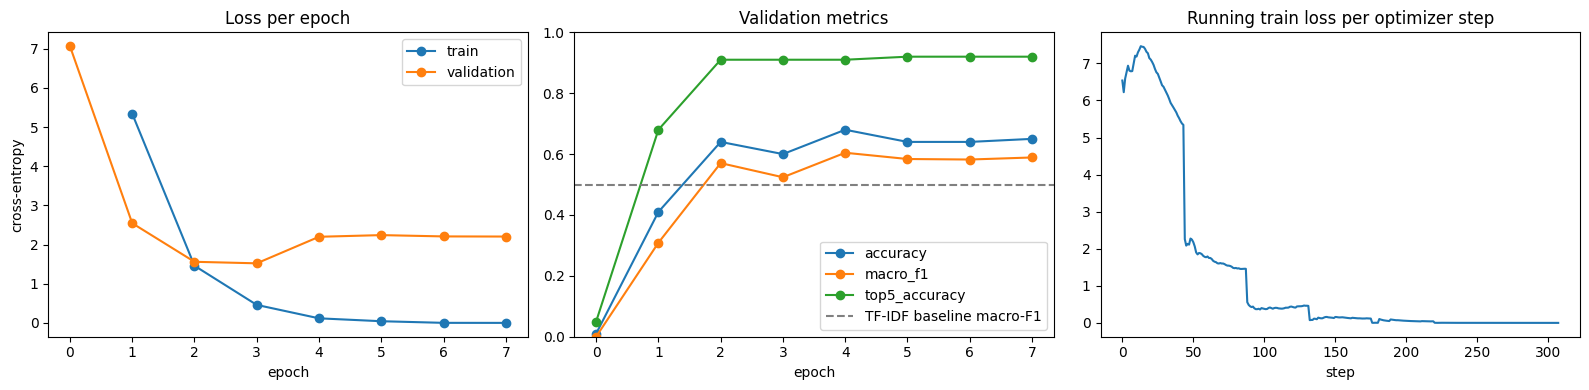

,accuracy,macro_precision,macro_recall,macro_f1,top5_accuracy,loss
0,0.01,0.000,0.010,0.000,0.05,7.066
1,0.41,0.274,0.409,0.309,0.68,2.545
2,0.64,0.542,0.641,0.570,0.91,1.560
3,0.60,0.496,0.601,0.524,0.91,1.521
4,0.68,0.572,0.677,0.604,0.91,2.199
5,0.64,0.559,0.636,0.584,0.92,2.241
6,0.64,0.557,0.636,0.582,0.92,2.208
7,0.65,0.562,0.646,0.589,0.92,2.205


In [ ]:
import matplotlib.pyplot as plt

PLOTS = OUT_DIR / "plots"; PLOTS.mkdir(exist_ok=True)
ep = history["epoch"]
val = pd.DataFrame(history["val"], index=ep)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(ep[1:], history["train_loss"][1:], "o-", label="train"); ax[0].plot(ep, val["loss"], "o-", label="validation")
ax[0].set(title="Loss per epoch", xlabel="epoch", ylabel="cross-entropy"); ax[0].legend()
for k in ["accuracy", "macro_f1", "top5_accuracy"]:
    ax[1].plot(ep, val[k], "o-", label=k)
ax[1].axhline(baseline["val"]["macro_f1"], ls="--", c="gray", label="TF-IDF baseline macro-F1")
ax[1].set(title="Validation metrics", xlabel="epoch", ylim=(0, 1)); ax[1].legend()
ax[2].plot(history["step_loss"]); ax[2].set(title="Running train loss per optimizer step", xlabel="step")
plt.tight_layout(); plt.savefig(PLOTS / "training_curves.png", dpi=150); plt.show()
val.round(3)

## Part 9. Final evaluation on the test set

Now, once, we load the **best** epoch's weights (chosen on validation) and score the untouched test set. These are the numbers you report.

- **Accuracy**: share of stories with the right genre.
- **Precision** for a genre: of the stories we *called* "Cyberpunk", how many were? **Recall**: of the real Cyberpunk stories, how many did we find? **F1** balances the two. "Macro" averages them over the 100 genres with equal weight.
- With 2 test stories per genre, each genre's recall is 0, 0.5 or 1, so look at per-genre numbers as hints, not verdicts.

In [ ]:
from safetensors.torch import load_file

set_peft_model_state_dict(peft_model, load_file(BEST_DIR / "adapter_model.safetensors"))
clf.head.load_state_dict(torch.load(BEST_DIR / "head.pt", map_location=DEVICE))
test_m, test_probs, test_labels = evaluate(clf, test_loader)
test_pred = test_probs.argmax(1)

comparison = pd.DataFrame({"TF-IDF + LogReg": baseline["test"], f"{MODEL_ID.split('/')[-1]} QLoRA + head": test_m}).T
comparison.drop(columns="loss", errors="ignore").round(3)

,accuracy,macro_precision,macro_recall,macro_f1,top5_accuracy
TF-IDF + LogReg,0.570,0.547,0.566,0.531,0.92
Qwen3-4B-Instruct-2507 QLoRA + head,0.695,0.671,0.692,0.658,0.94


In [ ]:
from sklearn.metrics import classification_report

report = pd.DataFrame(classification_report(test_labels, test_pred, labels=range(NUM_LABELS), target_names=genres,
                                            output_dict=True, zero_division=0)).T
per_genre = report.iloc[:NUM_LABELS].sort_values("f1-score")
print("Hardest genres:"); display(per_genre.head(15).round(2))
print("Genres with F1 = 1.0:", (per_genre["f1-score"] == 1).sum(), "of", NUM_LABELS)

Hardest genres:


,precision,recall,f1-score,support
Alternate Reality,0.0,0.0,0.0,2.0
Alternate History,0.0,0.0,0.0,2.0
Experimental,0.0,0.0,0.0,2.0
Futuristic,0.0,0.0,0.0,2.0
Mystery Thriller,0.0,0.0,0.0,2.0
Philosophical Fiction,0.0,0.0,0.0,2.0
Inspirational,0.0,0.0,0.0,2.0
Hard Science Fiction,0.0,0.0,0.0,2.0
Techno-Thriller,0.0,0.0,0.0,2.0
Supernatural Drama,0.0,0.0,0.0,2.0


Genres with F1 = 1.0: 37 of 99


### 9.1 Confusion matrix, grouped so confusions sit together

A 100 × 100 matrix in alphabetical order looks like noise. We reorder the genres with **hierarchical clustering** on the model's confusions (using the predicted probabilities, which are richer than the hard counts on 200 stories), so genres the model mixes up end up next to each other and show as blocks near the diagonal.

Then we list the most confused pairs. Expect sibling sub-genres (two kinds of fantasy, two kinds of thriller). For each, ask: *would a human also struggle to tell these apart from one story?* That makes a strong paragraph in your "challenges" section.

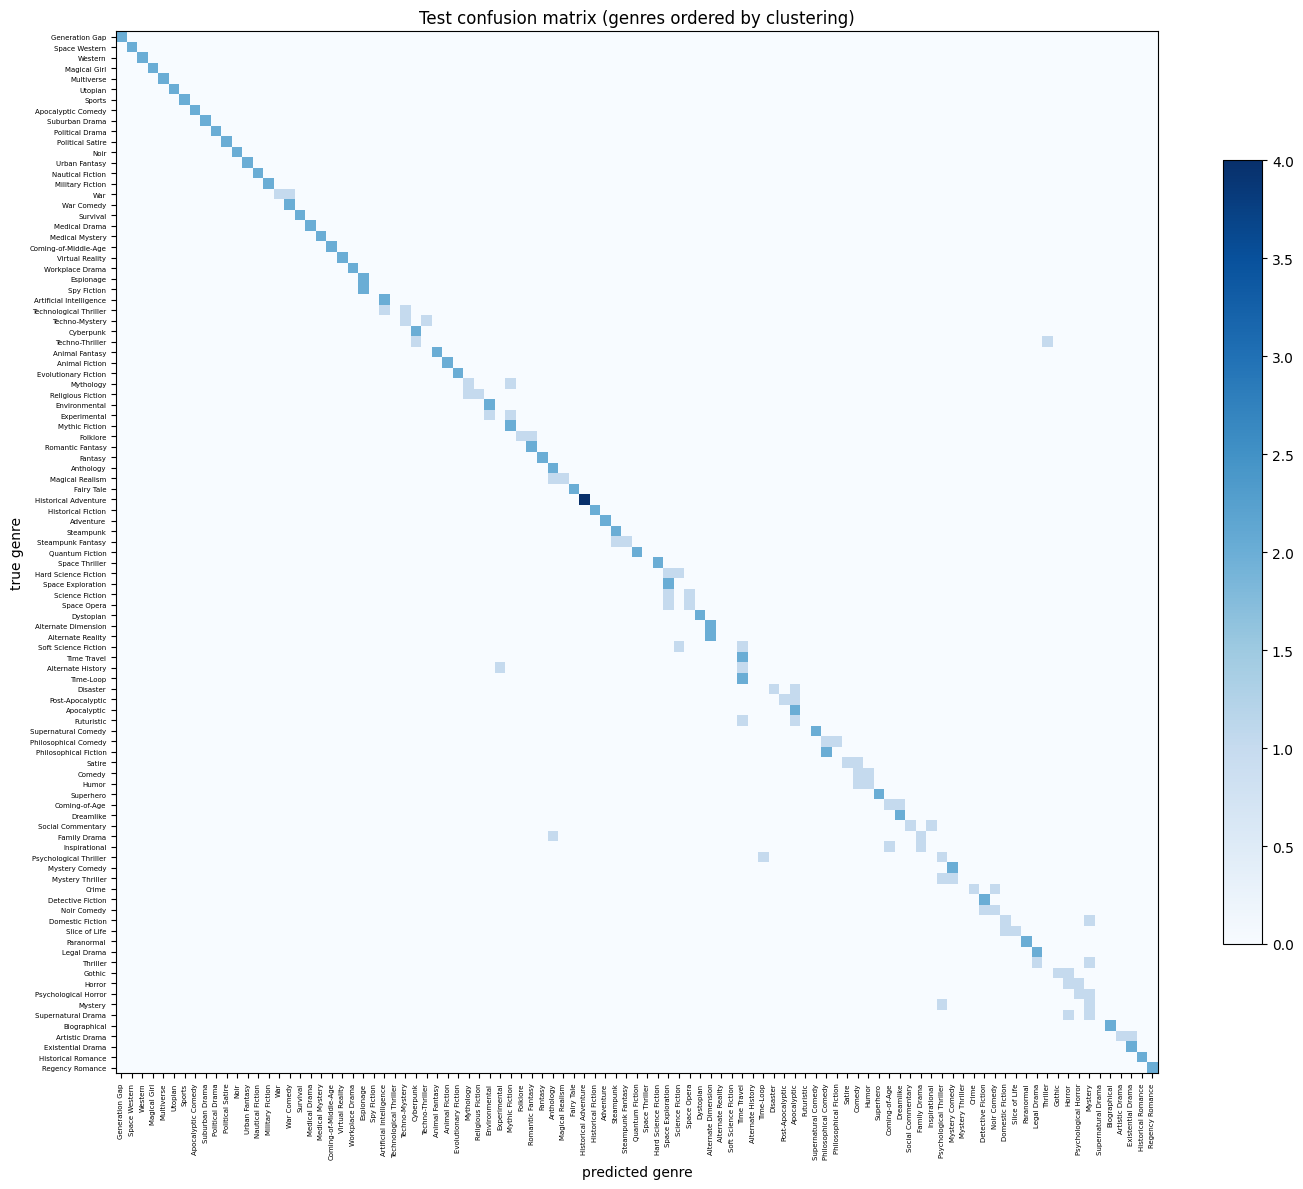

,mistakes (both directions),genre A,genre B
0,3,Philosophical Comedy,Philosophical Fiction
1,2,Time Travel,Time-Loop
2,2,Hard Science Fiction,Space Thriller
3,2,Espionage,Spy Fiction
4,2,Comedy,Humor
5,2,Alternate Dimension,Alternate Reality
6,1,War,War Comedy
7,1,Techno-Thriller,Thriller
8,1,Techno-Mystery,Technological Thriller
9,1,Techno-Mystery,Techno-Thriller


In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, leaves_list

cm = confusion_matrix(test_labels, test_pred, labels=range(NUM_LABELS))
soft = np.zeros((NUM_LABELS, NUM_LABELS))                    # average predicted probabilities per true genre
for y, p in zip(test_labels, test_probs):
    soft[y] += p
sim = (soft + soft.T) / 2
order = leaves_list(linkage(sim, method="average", metric="cosine")) if np.isfinite(sim).all() and sim.sum() > 0 else np.arange(NUM_LABELS)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm[np.ix_(order, order)], cmap="Blues")
ax.set_xticks(range(NUM_LABELS)); ax.set_yticks(range(NUM_LABELS))
ax.set_xticklabels([genres[i] for i in order], rotation=90, fontsize=5); ax.set_yticklabels([genres[i] for i in order], fontsize=5)
ax.set(xlabel="predicted genre", ylabel="true genre", title="Test confusion matrix (genres ordered by clustering)")
plt.colorbar(im, fraction=0.03); plt.tight_layout(); plt.savefig(PLOTS / "confusion_matrix.png", dpi=200); plt.show()

off = [(cm[i, j] + cm[j, i], genres[i], genres[j]) for i in range(NUM_LABELS) for j in range(i + 1, NUM_LABELS) if cm[i, j] + cm[j, i] > 0]
pd.DataFrame(sorted(off, reverse=True)[:15], columns=["mistakes (both directions)", "genre A", "genre B"])

## Part 10. Prove the chatbot is unchanged

This is the brief's "critical requirement". We give two independent pieces of evidence:

1. **The frozen weights did not change** (the SHA-256 check in 7.6).
2. **The chatbot's answers did not change.** We throw away the training model, load a fresh 4-bit base model *exactly as the chatbot serves it*, attach the trained adapter and head, and re-ask the Part 5 questions inside `with model.disable_adapter():`. With greedy decoding the answers must be identical, token for token, to the saved "before" answers.

As a **contrast**, we also ask the same questions with the adapter switched **on**. The adapter was trained only to make the last hidden state good for classification, with no language-modelling objective, so it is free to disturb text generation. Seeing answers change here shows what would happen if we had merged the adapter into the weights, i.e. the catastrophic forgetting our design avoids. That before / adapter-off / adapter-on table is the evidence the interview will want to see.

*Note:* run Parts 5 and 10 on the same GPU type. Different GPUs can use different low-level kernels, which can flip a greedy tie on rare tokens even with identical weights.

In [ ]:
# Free the training objects so the reload starts from a clean GPU
del clf, peft_model, base, optimizer, scheduler, scaler, lora_params
gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

from peft import PeftModel
served_base = load_base_model()                               # exactly how the Task 1 chatbot loads it
served = PeftModel.from_pretrained(served_base, BEST_DIR)    # attaches the adapter; base weights untouched
served.eval()
served_clf = GenreClassifier(served, NUM_LABELS)
served_clf.head.load_state_dict(torch.load(BEST_DIR / "head.pt", map_location=DEVICE))
served_clf.eval()
gpu_gb("chatbot + classifier loaded together:")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

chatbot + classifier loaded together: GPU allocated 4.78 GB | peak 5.23 GB


In [ ]:
def compare(before, after):
    same = [b["tokens"] == a["tokens"] for b, a in zip(before, after)]
    return sum(same), len(same)

with served.disable_adapter():
    qa_after_off = [answer(served, it) for it in qa_items]
qa_after_on = [answer(served, it) for it in qa_items]          # adapter ON: the contrast

json.dump({"adapter_off": qa_after_off, "adapter_on": qa_after_on}, open(OUT_DIR / "qa_after.json", "w"), indent=1)
same_off, n = compare(qa_before, qa_after_off)
same_on, _ = compare(qa_before, qa_after_on)
print(f"adapter OFF (how the chatbot runs): {same_off}/{n} answers identical to before training")
print(f"adapter ON  (contrast):              {same_on}/{n} answers identical to before training")

adapter OFF (how the chatbot runs): 15/15 answers identical to before training
adapter ON  (contrast):              0/15 answers identical to before training


In [ ]:
import difflib
first_diff = next((i for i, (b, a) in enumerate(zip(qa_before, qa_after_on)) if b["tokens"] != a["tokens"]), None)
if first_diff is not None:
    print("Example of what the adapter changes when left ON\nQ:", qa_items[first_diff]["question"])
    print("\nBEFORE / adapter OFF:\n", qa_before[first_diff]["text"][:500])
    print("\nadapter ON:\n", qa_after_on[first_diff]["text"][:500])
mismatch_off = [i for i, (b, a) in enumerate(zip(qa_before, qa_after_off)) if b["tokens"] != a["tokens"]]
if mismatch_off:
    i = mismatch_off[0]
    print(f"\n{len(mismatch_off)} adapter-OFF answers differ. First one, where it diverges:")
    print("\n".join(list(difflib.unified_diff(qa_before[i]["text"].split(), qa_after_off[i]["text"].split(), lineterm="", n=3))[:30]))
    print("Check: same GPU type as Part 5? Same MODEL_ID and transformers/bitsandbytes versions?")

Example of what the adapter changes when left ON
Q: Summarize this story in two sentences.

BEFORE / adapter OFF:
 In the tranquil town of Whispering Shadows, detective Johnathan investigates a mysterious figure seen at night, only to discover it is his long-lost brother Thomas, who has been living in secret due to a painful illness. Together, they find a cure through a groundbreaking medical trial, allowing Thomas to regain his sense of feeling and reunite with their community.

adapter ON:
 Johnathan, a detective new to the tranquil town of Whispering Shadows, investigates a mysterious figure seen at night, only to discover it is his long-lost brother Thomas, who has been living in secrecy due to a painful illness. Together, they work to find a cure, ultimately helping Thomas regain his sense of feeling and reintegrate into the community, bringing an end to the shadows that haunted the town.


**What to expect:** adapter OFF should be `n/n` identical. Adapter ON will usually differ on many answers; if it happens to be close, that is fine too, and still worth reporting honestly: it means this adapter interferes little, but the design guarantees safety either way.

When your Task 1 evaluation set is ready, also run its retrieval and answer metrics (hit rate, judge scores) with the adapter off and show they match the Task 1 numbers. Identical answers imply identical scores, but reviewers like to see the table.

## Part 11. One model, both tasks

The reloaded model now serves **both** tasks from a single copy of the weights in GPU memory. The classifier path turns the adapter on (the default); the chatbot path wraps generation in `disable_adapter()`. First we check the reloaded classifier reproduces the test score (so the saved files are complete), then try a prediction.

In [ ]:
reloaded_m, _, _ = evaluate(served_clf, test_loader)
print(f"test accuracy: training session {test_m['accuracy']:.3f} | reloaded {reloaded_m['accuracy']:.3f}")

@torch.no_grad()
def predict_genre(title, story, k=3):
    ids, _, _ = encode(title, story)
    batch = collate([(ids, 0)])
    with autocast():
        logits = served_clf(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
    probs = logits.float().softmax(-1)[0]
    top = probs.topk(k)
    return [(id2label[i.item()], round(p.item(), 3)) for p, i in zip(top.values, top.indices)]

r = test_df.iloc[0]
print(f"\n'{r.title}' | true genre: {r.genre}\npredicted:", predict_genre(r.title, r.story))

peak_serve_gb = torch.cuda.max_memory_allocated() / 2**30 if torch.cuda.is_available() else float("nan")
print(f"\npeak GPU memory serving chat + classification: {peak_serve_gb:.2f} GB (budget 24 GB)")

test accuracy: training session 0.695 | reloaded 0.695

'Echoes of Whispered Shadows' | true genre: Mystery
predicted: [('Psychological Thriller', 0.4), ('Mystery', 0.384), ('Thriller', 0.151)]

peak GPU memory serving chat + classification: 6.36 GB (budget 24 GB)


### 11.1 Save a results summary for the write-up

Everything the Task 2 document needs, in one JSON file next to the plots on Drive.

In [ ]:
results = {
    "model": MODEL_ID, "quantization": "4-bit NF4, double quant, fp16 compute",
    "hyperparameters": {"max_len": MAX_LEN, "use_title": USE_TITLE, "lora_r": LORA_R, "lora_alpha": LORA_ALPHA,
                        "lora_dropout": LORA_DROPOUT, "targets": LORA_TARGETS, "lr_lora": LR_LORA, "lr_head": LR_HEAD,
                        "epochs_max": EPOCHS, "batch": BATCH_SIZE, "grad_accum": GRAD_ACCUM, "warmup": WARMUP_RATIO,
                        "patience": PATIENCE, "seed": SEED},
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "train_minutes_last_session": round(train_minutes, 1), "peak_train_gb": round(peak_train_gb, 2),
    "peak_serve_both_gb": round(peak_serve_gb, 2),
    "best_val_macro_f1": best_f1, "test": test_m, "baseline_test": baseline["test"],
    "history": {"epoch": history["epoch"], "train_loss": history["train_loss"], "val": history["val"]},
    "preservation": {"frozen_sha256_identical": fp_before == fp_after, "adapter_off_identical": f"{same_off}/{n}",
                     "adapter_on_identical": f"{same_on}/{n}"},
}
json.dump(results, open(OUT_DIR / "results.json", "w"), indent=1, default=float)
print("saved", OUT_DIR / "results.json")

saved /content/drive/MyDrive/LORA/story-chatbot/task2/Qwen3-4B-Instruct-2507/results.json


## What you've built, and where to go next

You now have a LoRA adapter and a head (a few tens of MB on Drive) that turn the chatbot's LLM into a 100-genre classifier, plus evidence that the chatbot itself is unchanged.

### Check your understanding

Try answering these without looking back; they are the questions an interviewer is likely to ask.

1. Why does the classifier read the *last* token's hidden state and not the first?
2. Why must truncation keep the suffix, and why do we pad on the right here but on the left for generation?
3. What exactly does `disable_adapter()` switch off, and why does that guarantee the chatbot is unchanged?
4. Why does the head get a 10× larger learning rate than LoRA?
5. What does the GradScaler protect against, and why don't you need it with bf16?
6. Why is macro-F1 a better early-stopping signal than accuracy here? (Hint: are the classes balanced? Would it matter if they weren't?)
7. Your test set has 200 stories. Roughly how much could accuracy move if 4 more stories were right or wrong?

### Experiments worth adding (each is a row in your write-up)

- **Ablations**: `LORA_R` 8 vs 16 vs 32; `USE_TITLE` True vs False; `MAX_LEN` 512 vs 1024. Change one knob, re-run Parts 3 to 9, and use a fresh `OUT_DIR` for each (append the setting to the folder name).
- **Seeds**: re-run the final config with seeds 42, 43, 44 and report mean ± std.
- **5-fold cross-validation**: 200 test stories give noisy numbers. Re-split train+val+test into 5 stratified folds (2 stories per genre each), train on 4, test on 1, and report the average. It costs 5 training runs, so do it last.
- **Window augmentation**: split long stories into 2 to 3 overlapping windows as extra training examples, and average the logits over windows at prediction time.
- **The merged-adapter contrast**: the adapter-ON run in Part 10 already shows the effect; merging (`merge_and_unload`) into a 16-bit copy shows the same thing in the form most people mean by "fine-tuning the model".

### For `docs/task2_classifier.md`

The brief's checklist and where this notebook answers it: preprocessing (Parts 1 to 3), method and why (Part 6 and the task plan's approach table), hyperparameters with reasons (config cell), training time and hardware (`results.json`), metrics and how they evolve (Parts 8 and 9, plots in `plots/`), preservation evidence (Part 10), challenges (keep notes as you go: tiny data per genre, sibling genres, truncation, fp16 on a T4).